<a href="https://colab.research.google.com/github/zahid-shovon/aml_rfi_smap/blob/main/RFI_Detection_SMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install and import
!pip -q install h5py seaborn scikit-learn tensorflow openpyxl

import os
import warnings
warnings.filterwarnings("ignore")

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, balanced_accuracy_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries loaded.")

Libraries loaded.


Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Set file path

In [ ]:
file_path = "/content/drive/MyDrive/AML/Data/SMAP_L1B_TB_59906_A_20260419T160238_R19240_001.h5"
print("Exists:", os.path.exists(file_path))

Exists: True


Print file structure

In [ ]:
with h5py.File(file_path, "r") as f:
    def print_name(name):
        print(name)
    f.visit(print_name)

Brightness_Temperature
Brightness_Temperature/antenna_earth_azimuth
Brightness_Temperature/antenna_look_angle
Brightness_Temperature/antenna_scan_angle
Brightness_Temperature/antenna_sidelobe_correction_3
Brightness_Temperature/antenna_sidelobe_correction_4
Brightness_Temperature/antenna_sidelobe_correction_h
Brightness_Temperature/antenna_sidelobe_correction_v
Brightness_Temperature/atm_correction_h
Brightness_Temperature/atm_correction_v
Brightness_Temperature/atm_loss
Brightness_Temperature/earth_boresight_azimuth
Brightness_Temperature/earth_boresight_incidence
Brightness_Temperature/faraday_rotation_angle
Brightness_Temperature/faraday_rotation_correction_h
Brightness_Temperature/faraday_rotation_correction_v
Brightness_Temperature/footprint_surface_status
Brightness_Temperature/galactic_direct_correction_h
Brightness_Temperature/galactic_direct_correction_v
Brightness_Temperature/galactic_reflected_correction_3
Brightness_Temperature/galactic_reflected_correction_4
Brightness_Tem

Extract selected variables

In [ ]:
with h5py.File(file_path, "r") as f:
    tb_h = f["Brightness_Temperature/tb_h"][:]
    tb_v = f["Brightness_Temperature/tb_v"][:]
    tb_lat = f["Brightness_Temperature/tb_lat"][:]
    tb_lon = f["Brightness_Temperature/tb_lon"][:]
    incidence = f["Brightness_Temperature/earth_boresight_incidence"][:]
    nedt_h = f["Brightness_Temperature/nedt_h"][:]
    nedt_v = f["Brightness_Temperature/nedt_v"][:]
    qual_flag_h = f["Brightness_Temperature/tb_qual_flag_h"][:]

print("tb_h:", tb_h.shape)
print("tb_v:", tb_v.shape)
print("tb_lat:", tb_lat.shape)
print("tb_lon:", tb_lon.shape)
print("incidence:", incidence.shape)
print("nedt_h:", nedt_h.shape)
print("nedt_v:", nedt_v.shape)
print("qual_flag_h:", qual_flag_h.shape)

tb_h: (779, 241)
tb_v: (779, 241)
tb_lat: (779, 241)
tb_lon: (779, 241)
incidence: (779, 241)
nedt_h: (779, 241)
nedt_v: (779, 241)
qual_flag_h: (779, 241)


Check sample values

In [ ]:
print("tb_h sample:", tb_h.flatten()[:10])
print("tb_v sample:", tb_v.flatten()[:10])
print("tb_lat sample:", tb_lat.flatten()[:10])
print("tb_lon sample:", tb_lon.flatten()[:10])
print("incidence sample:", incidence.flatten()[:10])
print("nedt_h sample:", nedt_h.flatten()[:10])
print("nedt_v sample:", nedt_v.flatten()[:10])
print("qual_flag_h sample:", qual_flag_h.flatten()[:20])
print("Unique quality flags (first 20 unique):", np.unique(qual_flag_h.flatten())[:20])

tb_h sample: [190.74265 191.08319 191.7156  192.49196 190.15952 188.81914 191.54012
 189.47069 191.15523 192.44978]
tb_v sample: [212.48969 213.06985 214.42291 212.50134 209.95566 214.94421 213.0236
 212.60847 211.5099  211.69264]
tb_lat sample: [-75.34759  -75.410065 -75.47443  -75.54072  -75.60893  -75.67905
 -75.75107  -75.82503  -75.90082  -75.97843 ]
tb_lon sample: [148.84975 148.43257 148.0188  147.60811 147.20062 146.79648 146.39569
 145.99812 145.6043  145.21439]
incidence sample: [40.09215  40.09219  40.09221  40.092197 40.092155 40.092087 40.09199
 40.09187  40.09181  40.091774]
nedt_h sample: [0.87166786 0.88327664 0.9437519  1.0722535  0.8937295  0.9652836
 1.0502409  0.97025627 0.86407    0.9350244 ]
nedt_v sample: [1.0801871 1.0054616 1.0621053 0.985425  0.9735455 1.0291233 1.1726922
 1.0640901 1.0388628 1.0339854]
qual_flag_h sample: [8192 8192 8192 8192 8192 8192 8192 8192 8192 8192 8192 8192 8192 8192
 8192 8192 8192 8192 8192 8192]
Unique quality flags (first 20 uniqu

Build a dataframe

In [ ]:
df = pd.DataFrame({
    "tb_h": np.ravel(tb_h),
    "tb_v": np.ravel(tb_v),
    "tb_lat": np.ravel(tb_lat),
    "tb_lon": np.ravel(tb_lon),
    "incidence": np.ravel(incidence),
    "nedt_h": np.ravel(nedt_h),
    "nedt_v": np.ravel(nedt_v),
    "qual_flag_h": np.ravel(qual_flag_h)
})

print(df.shape)
df.head()

(187739, 8)


,tb_h,tb_v,tb_lat,tb_lon,incidence,nedt_h,nedt_v,qual_flag_h
0,190.742645,212.489685,-75.347588,148.849747,40.092152,0.871668,1.080187,8192
1,191.083191,213.069855,-75.410065,148.432571,40.092190,0.883277,1.005462,8192
2,191.715607,214.422913,-75.474426,148.018799,40.092209,0.943752,1.062105,8192
3,192.491959,212.501343,-75.540718,147.608109,40.092197,1.072253,0.985425,8192
4,190.159515,209.955658,-75.608932,147.200623,40.092155,0.893730,0.973545,8192


Clean the dataframe

In [ ]:
df = df.replace([np.inf, -np.inf], np.nan)

# Convert fill values or impossible values to NaN if needed
for col in ["tb_h", "tb_v", "tb_lat", "tb_lon", "incidence", "nedt_h", "nedt_v"]:
    df.loc[np.abs(df[col]) > 1e10, col] = np.nan

df = df.dropna().copy()

print("Shape after cleaning:", df.shape)
print(df.describe())

Shape after cleaning: (187739, 8)
                tb_h           tb_v         tb_lat         tb_lon  \
count  187739.000000  187739.000000  187739.000000  187739.000000   
mean       31.551334      56.805161     -58.563805     -37.280643   
std      1237.292236    1240.036011     765.124023     766.054260   
min     -9999.000000   -9999.000000   -9999.000000   -9999.000000   
25%        77.693111     116.181988     -48.910557       9.636959   
50%       204.163040     225.754791      -0.510939      22.234472   
75%       255.066925     272.441010      48.010340      34.379416   
max       300.900085     344.365540      86.465027     179.982956   

           incidence         nedt_h         nedt_v    qual_flag_h  
count  187739.000000  187739.000000  187739.000000  187739.000000  
mean      -18.876522    -124.711105    -126.574875    1089.666036  
std       765.873535    1114.322998    1122.525879    4308.865413  
min     -9999.000000   -9999.000000   -9999.000000       0.000000  
25% 

Binary quality-affected label derived from the SMAP horizontal brightness temperature quality flag--Create target label - where 0 if qual_flag_h == 0 and
1 if qual_flag_h != 0

In [ ]:
df["target"] = (df["qual_flag_h"] != 0).astype(int)

print(df["target"].value_counts())
df[["qual_flag_h", "target"]].head(10)

target
0    157640
1     30099
Name: count, dtype: int64


,qual_flag_h,target
0,8192,1
1,8192,1
2,8192,1
3,8192,1
4,8192,1
5,8192,1
6,8192,1
7,8192,1
8,8192,1
9,8192,1


Basic sanity filtering

In [ ]:
df = df[
    (df["tb_lat"] >= -90) & (df["tb_lat"] <= 90) &
    (df["tb_lon"] >= -180) & (df["tb_lon"] <= 180)
].copy()

print("Shape after geophysical sanity checks:", df.shape)
print(df["target"].value_counts(normalize=True))

Shape after geophysical sanity checks: (186638, 9)
target
0    0.84463
1    0.15537
Name: proportion, dtype: float64


Data analysis and mining

Descriptive statistics

In [ ]:
desc = df[["tb_h", "tb_v", "tb_lat", "tb_lon", "incidence", "nedt_h", "nedt_v"]].describe().T
desc["mode"] = df[["tb_h", "tb_v", "tb_lat", "tb_lon", "incidence", "nedt_h", "nedt_v"]].mode().iloc[0]
desc["variance"] = df[["tb_h", "tb_v", "tb_lat", "tb_lon", "incidence", "nedt_h", "nedt_v"]].var()
desc

,count,mean,std,min,25%,50%,75%,max,mode,variance
tb_h,186638.0,90.722755,971.231079,-9999.000000,77.864412,204.828598,255.251678,300.900085,-9999.000000,943289.812500
tb_v,186638.0,116.125557,973.132507,-9999.000000,116.313379,226.310013,272.611992,344.365540,-9999.000000,946986.875000
tb_lat,186638.0,0.076014,53.297707,-86.586456,-48.087460,0.057071,48.290361,86.465027,-77.763283,2840.645508
tb_lon,186638.0,21.484743,44.189606,-179.982529,9.979166,22.353570,34.491107,179.982956,21.307867,1952.721313
incidence,186638.0,39.997425,0.057772,39.923706,39.956230,39.977547,40.044117,40.096985,39.977623,0.003338
nedt_h,186638.0,-66.461487,819.103638,-9999.000000,0.816525,1.000925,1.108936,15.824272,-9999.000000,670930.750000
nedt_v,186638.0,-68.336258,830.589539,-9999.000000,0.881947,1.038138,1.143003,15.920555,-9999.000000,689878.937500


Class balance plot

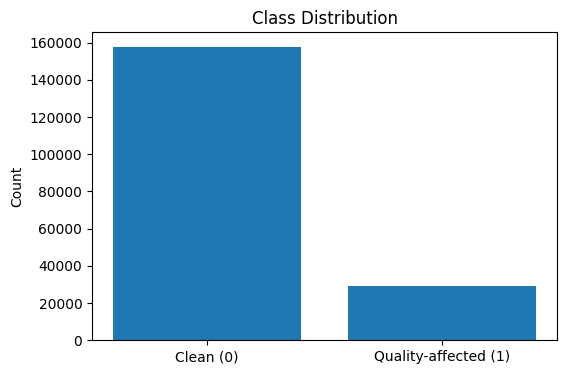

In [ ]:
class_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(["Clean (0)", "Quality-affected (1)"], class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

Histograms

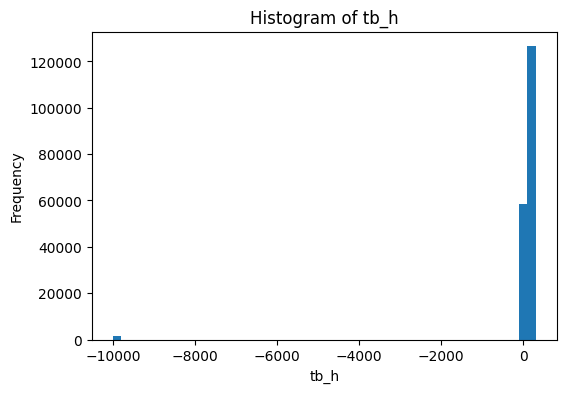

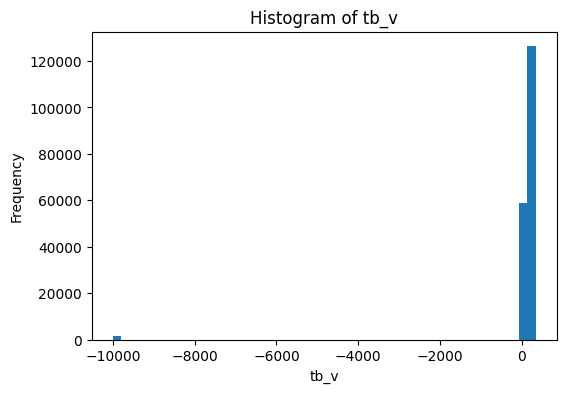

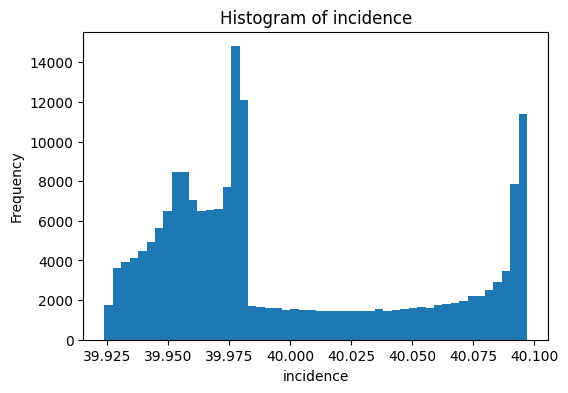

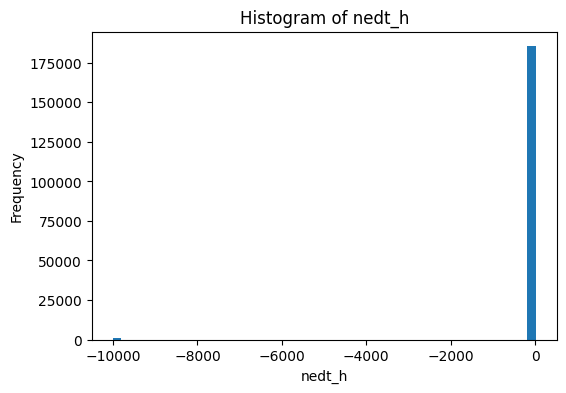

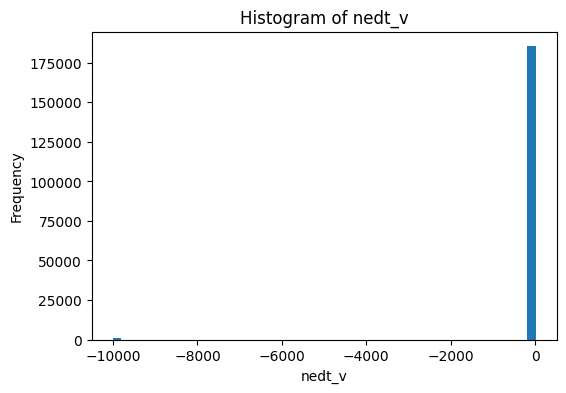

In [ ]:
features = ["tb_h", "tb_v", "incidence", "nedt_h", "nedt_v"]

for col in features:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=50)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Boxplots by class

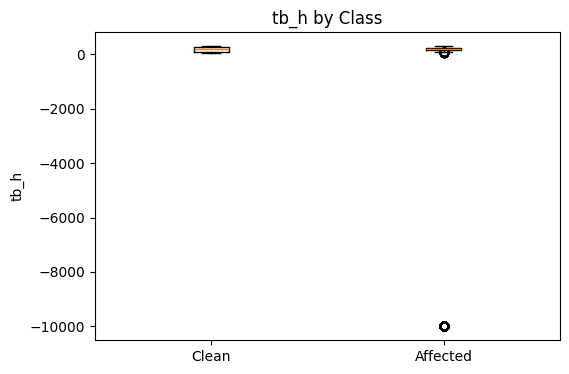

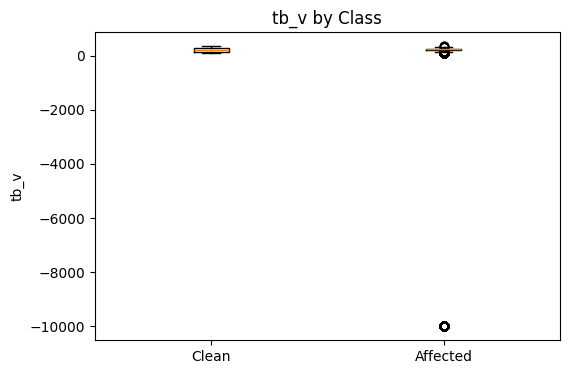

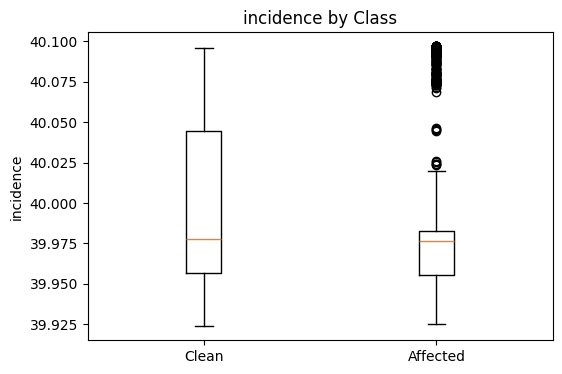

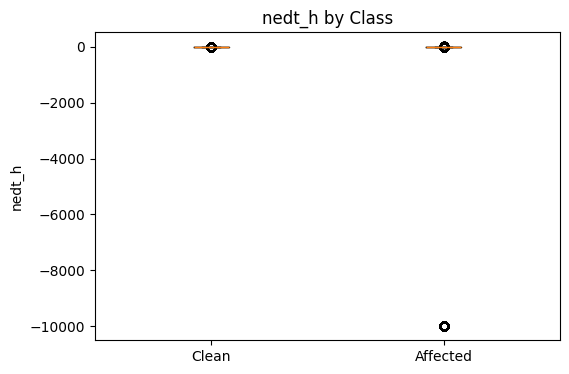

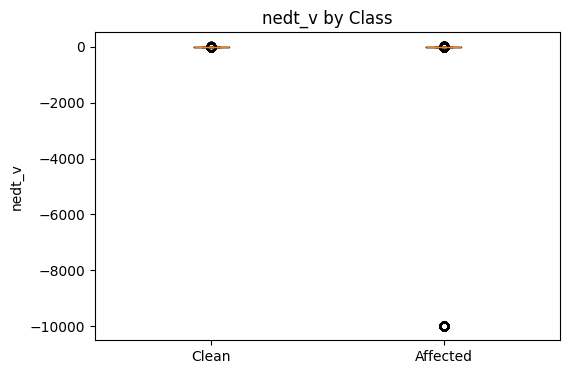

In [ ]:
for col in features:
    plt.figure(figsize=(6,4))
    data0 = df[df["target"] == 0][col]
    data1 = df[df["target"] == 1][col]
    plt.boxplot([data0, data1], labels=["Clean", "Affected"])
    plt.title(f"{col} by Class")
    plt.ylabel(col)
    plt.show()

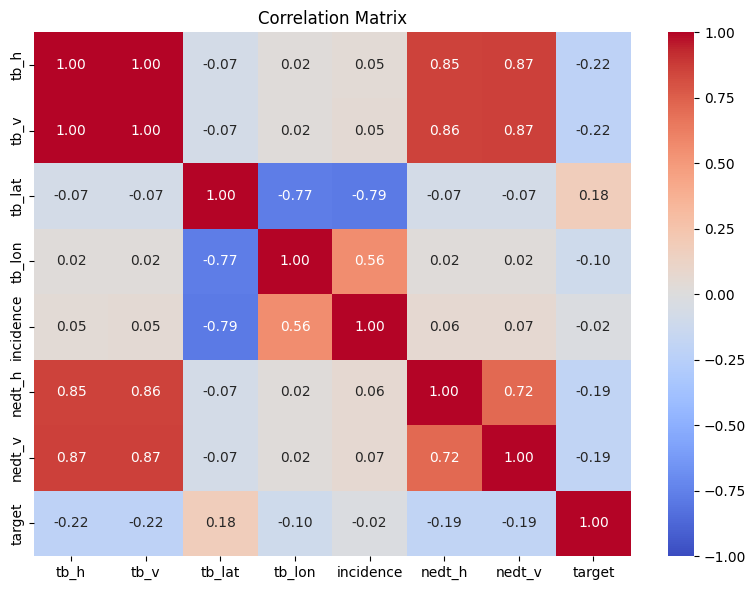

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[["tb_h", "tb_v", "tb_lat", "tb_lon", "incidence", "nedt_h", "nedt_v", "target"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Correlation matrix

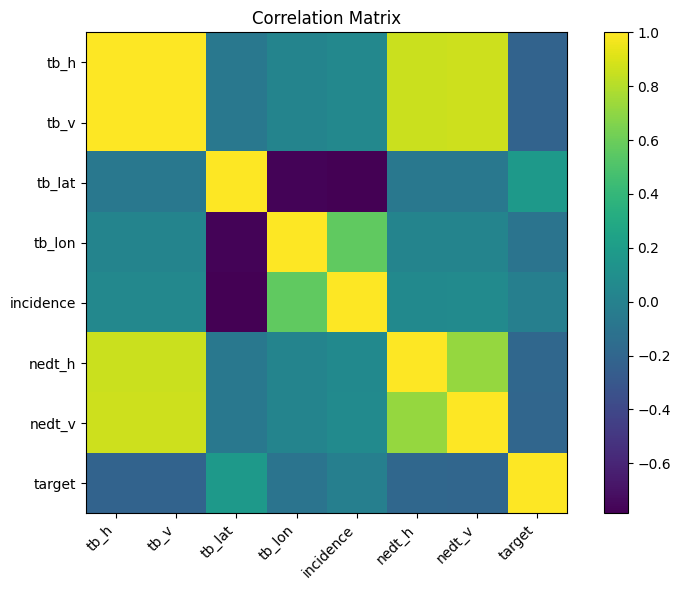

,tb_h,tb_v,tb_lat,tb_lon,incidence,nedt_h,nedt_v,target
tb_h,1.000000,0.999928,-0.071407,0.017252,0.046209,0.854570,0.865465,-0.215775
tb_v,0.999928,1.000000,-0.071952,0.017868,0.047984,0.855190,0.866091,-0.217437
tb_lat,-0.071407,-0.071952,1.000000,-0.769123,-0.786069,-0.071196,-0.071232,0.177645
tb_lon,0.017252,0.017868,-0.769123,1.000000,0.561226,0.021506,0.019265,-0.101878
incidence,0.046209,0.047984,-0.786069,0.561226,1.000000,0.064468,0.067183,-0.017270
nedt_h,0.854570,0.855190,-0.071196,0.021506,0.064468,1.000000,0.716154,-0.192064
nedt_v,0.865465,0.866091,-0.071232,0.019265,0.067183,0.716154,1.000000,-0.194828
target,-0.215775,-0.217437,0.177645,-0.101878,-0.017270,-0.192064,-0.194828,1.000000


In [ ]:
corr = df[["tb_h", "tb_v", "tb_lat", "tb_lon", "incidence", "nedt_h", "nedt_v", "target"]].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

corr

PCA visualisation

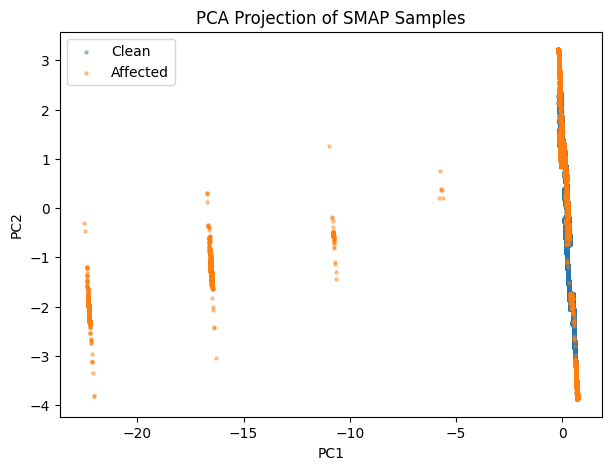

Explained variance ratio: [0.51581067 0.34159058]


In [ ]:
X_pca = df[["tb_h", "tb_v", "tb_lat", "tb_lon", "incidence", "nedt_h", "nedt_v"]].copy()
y_pca = df["target"].copy()

scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_pca)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled_pca)

plt.figure(figsize=(7,5))
plt.scatter(X_2d[y_pca==0, 0], X_2d[y_pca==0, 1], s=5, alpha=0.4, label="Clean")
plt.scatter(X_2d[y_pca==1, 0], X_2d[y_pca==1, 1], s=5, alpha=0.4, label="Affected")
plt.title("PCA Projection of SMAP Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

Define features and target

In [ ]:
feature_cols = ["tb_h", "tb_v", "tb_lat", "tb_lon", "incidence", "nedt_h", "nedt_v"]
X = df[feature_cols].copy()
y = df["target"].copy()

print(X.shape, y.shape)

(186638, 7) (186638,)


Train/test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (149310, 7) (149310,)
Test: (37328, 7) (37328,)


Baseline 1: Logistic Regression

In [ ]:
logreg_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

logreg_pipe.fit(X_train, y_train)
y_pred_lr = logreg_pipe.predict(X_test)
y_prob_lr = logreg_pipe.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression
[[23663  7865]
 [ 1244  4556]]
              precision    recall  f1-score   support

           0     0.9501    0.7505    0.8386     31528
           1     0.3668    0.7855    0.5001      5800

    accuracy                         0.7560     37328
   macro avg     0.6584    0.7680    0.6693     37328
weighted avg     0.8594    0.7560    0.7860     37328

ROC-AUC: 0.7747916247407887


Baseline 2: Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest
[[29379  2149]
 [  325  5475]]
              precision    recall  f1-score   support

           0     0.9891    0.9318    0.9596     31528
           1     0.7181    0.9440    0.8157      5800

    accuracy                         0.9337     37328
   macro avg     0.8536    0.9379    0.8876     37328
weighted avg     0.9470    0.9337    0.9372     37328

ROC-AUC: 0.9852648658226076


Deep model preprocessing

In [ ]:
scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_scaled = scaler_nn.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(149310, 7) (37328, 7)


Deep learning model - Deep Feedforward Neural Network (Multilayer Perceptron, MLP)

In [ ]:
tf.random.set_seed(42)

model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9090 - loss: 0.2292 - val_accuracy: 0.9252 - val_loss: 0.1593
Epoch 2/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9255 - loss: 0.1650 - val_accuracy: 0.9288 - val_loss: 0.1530
Epoch 3/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9270 - loss: 0.1601 - val_accuracy: 0.9335 - val_loss: 0.1512
Epoch 4/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9289 - loss: 0.1575 - val_accuracy: 0.9337 - val_loss: 0.1491
Epoch 5/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9298 - loss: 0.1554 - val_accuracy: 0.9318 - val_loss: 0.1476
Epoch 6/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9305 - loss: 0.1535 - val_accuracy: 0.9346 - val_loss: 0.1484
Epoch 7/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9308 - loss: 0.1526 - val_accuracy: 0.9335 - val_loss: 0.1458
Epoch 8/30
934/934 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9318 - loss: 0.1522 - val_accuracy: 0.

Evaluate deep model

In [ ]:
y_prob_nn = model.predict(X_test_scaled).ravel()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

print("Neural Network")
print(confusion_matrix(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nn))

1167/1167 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Neural Network
[[30477  1051]
 [ 1292  4508]]
              precision    recall  f1-score   support

           0     0.9593    0.9667    0.9630     31528
           1     0.8109    0.7772    0.7937      5800

    accuracy                         0.9372     37328
   macro avg     0.8851    0.8720    0.8784     37328
weighted avg     0.9363    0.9372    0.9367     37328

ROC-AUC: 0.967959386402016


Learning curves

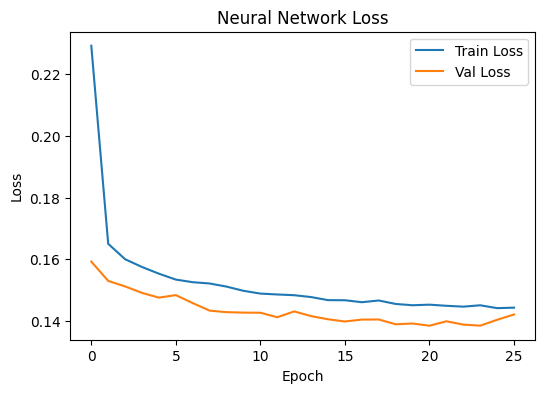

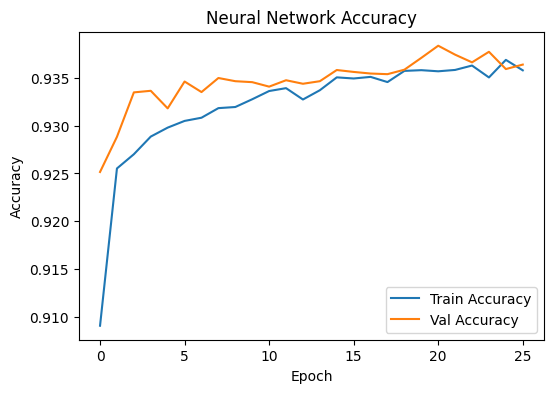

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Neural Network Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Neural Network Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Cross-validation for Random Forest

In [ ]:
rf_cv = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_cv, X, y, cv=cv, scoring="f1")

print("RF 5-fold CV F1 scores:", cv_scores)
print("Mean F1:", cv_scores.mean())
print("Std F1:", cv_scores.std())

RF 5-fold CV F1 scores: [0.81898933 0.81770911 0.8143535  0.81552532 0.82014388]
Mean F1: 0.8173442270502589
Std F1: 0.0021415160236017633


Random Forest tuning

In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12, 16],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_rf = grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_best_rf))
print(classification_report(y_test, y_pred_best_rf, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best_rf))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params: {'max_depth': 16, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV score: 0.8413178978891501
[[29917  1611]
 [  444  5356]]
              precision    recall  f1-score   support

           0     0.9854    0.9489    0.9668     31528
           1     0.7688    0.9234    0.8390      5800

    accuracy                         0.9449     37328
   macro avg     0.8771    0.9362    0.9029     37328
weighted avg     0.9517    0.9449    0.9469     37328

ROC-AUC: 0.9858880666555836


Model comparison table

In [ ]:
def metric_row(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    metric_row("Logistic Regression", y_test, y_pred_lr, y_prob_lr),
    metric_row("Random Forest", y_test, y_pred_rf, y_prob_rf),
    metric_row("Tuned Random Forest", y_test, y_pred_best_rf, y_prob_best_rf),
    metric_row("Neural Network", y_test, y_pred_nn, y_prob_nn)
])

results.sort_values("F1", ascending=False)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
2,Tuned Random Forest,0.944947,0.936175,0.768767,0.923448,0.839038,0.985888
1,Random Forest,0.933723,0.937902,0.718127,0.943966,0.815703,0.985265
3,Neural Network,0.937232,0.871953,0.810937,0.777241,0.793732,0.967959
0,Logistic Regression,0.755974,0.768028,0.366798,0.785517,0.500082,0.774792


ROC curves

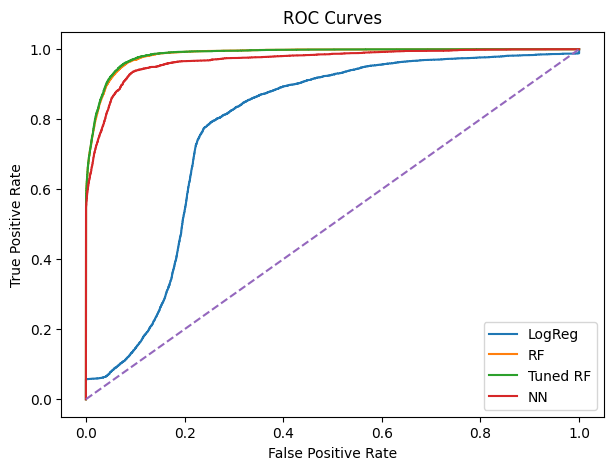

In [ ]:
plt.figure(figsize=(7,5))

for name, probs in [
    ("LogReg", y_prob_lr),
    ("RF", y_prob_rf),
    ("Tuned RF", y_prob_best_rf),
    ("NN", y_prob_nn)
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

Precision-recall curves

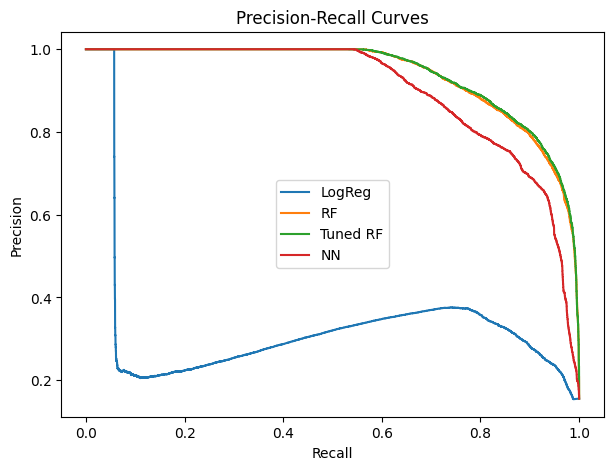

In [ ]:
plt.figure(figsize=(7,5))

for name, probs in [
    ("LogReg", y_prob_lr),
    ("RF", y_prob_rf),
    ("Tuned RF", y_prob_best_rf),
    ("NN", y_prob_nn)
]:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

Confusion matrix plot helper

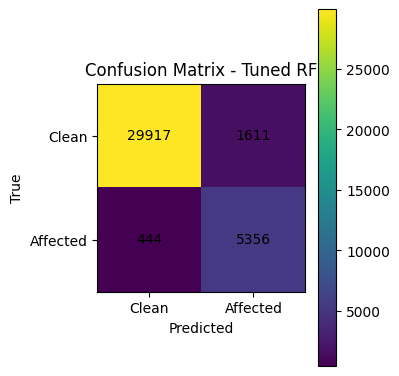

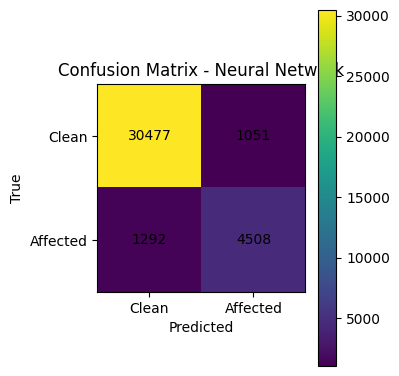

In [ ]:
def plot_cm(cm, title):
    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = [0, 1]
    labels = ["Clean", "Affected"]
    plt.xticks(ticks, labels)
    plt.yticks(ticks, labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()

plot_cm(confusion_matrix(y_test, y_pred_best_rf), "Confusion Matrix - Tuned RF")
plot_cm(confusion_matrix(y_test, y_pred_nn), "Confusion Matrix - Neural Network")

Feature importance

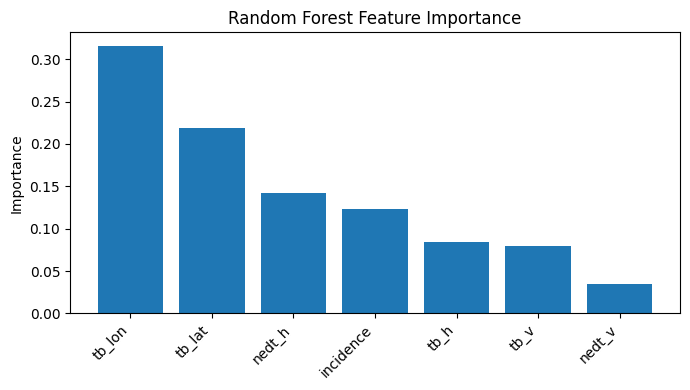

,Feature,Importance
3,tb_lon,0.315998
2,tb_lat,0.219347
5,nedt_h,0.142747
4,incidence,0.123640
0,tb_h,0.083774
1,tb_v,0.079242
6,nedt_v,0.035252


In [ ]:
importances = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(7,4))
plt.bar(importances["Feature"], importances["Importance"])
plt.xticks(rotation=45, ha="right")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

importances

Permutation importance

In [ ]:
perm = permutation_importance(best_rf, X_test, y_test, n_repeats=5, random_state=42, scoring="f1")

perm_df = pd.DataFrame({
    "Feature": feature_cols,
    "ImportanceMean": perm.importances_mean,
    "ImportanceStd": perm.importances_std
}).sort_values("ImportanceMean", ascending=False)

perm_df

Error analysis

Inspect misclassifications

In [ ]:
test_results = X_test.copy()
test_results["true"] = y_test.values
test_results["pred_rf"] = y_pred_best_rf
test_results["prob_rf"] = y_prob_best_rf
test_results["pred_nn"] = y_pred_nn
test_results["prob_nn"] = y_prob_nn

rf_errors = test_results[test_results["true"] != test_results["pred_rf"]]
nn_errors = test_results[test_results["true"] != test_results["pred_nn"]]

print("RF errors:", rf_errors.shape)
print("NN errors:", nn_errors.shape)

rf_errors.head(10)

RF errors: (2055, 12)
NN errors: (2343, 12)


,tb_h,tb_v,tb_lat,tb_lon,incidence,nedt_h,nedt_v,true,pred_rf,prob_rf,pred_nn,prob_nn
141886,251.368713,272.591309,45.058609,10.793744,39.969208,1.409435,1.209418,0,1,0.937656,1,0.624660
134749,260.871735,277.767578,46.107101,15.455598,39.952496,1.953689,2.907779,0,1,0.982699,1,0.598997
138741,80.597321,118.116333,41.798573,10.118458,39.966549,0.896636,0.898634,0,1,0.831479,1,0.523480
122989,78.290787,117.700150,33.464909,12.045567,39.944199,1.013754,0.788144,0,1,0.822911,0,0.363173
143650,167.027481,201.879257,53.979130,14.763742,39.954678,1.339081,1.473384,0,1,0.817292,0,0.489107
63922,225.522034,253.233688,-26.304350,28.694359,40.016663,1.302778,1.201339,0,1,0.549255,0,0.015234
118189,264.539307,289.301544,26.607624,12.157714,39.931728,1.932657,1.531973,0,1,0.852126,0,0.032002
130742,136.110748,172.796631,36.976143,7.960045,39.940651,1.338243,1.753243,0,1,0.712851,0,0.291180
148467,197.850571,226.336792,58.547749,13.530922,39.958900,1.297377,1.438370,0,1,0.717483,0,0.427767
117395,256.042450,284.537567,28.144415,19.947001,39.944969,1.320129,1.396861,0,1,0.581538,0,0.170057


Geospatial scatter

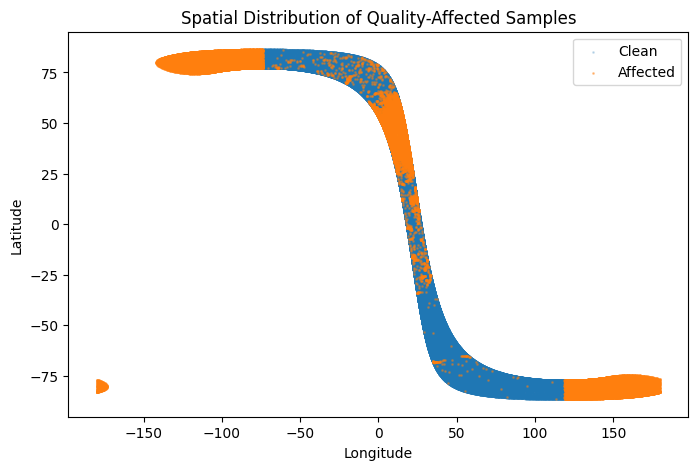

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df[df["target"]==0]["tb_lon"], df[df["target"]==0]["tb_lat"], s=1, alpha=0.2, label="Clean")
plt.scatter(df[df["target"]==1]["tb_lon"], df[df["target"]==1]["tb_lat"], s=1, alpha=0.4, label="Affected")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Quality-Affected Samples")
plt.legend()
plt.show()

Save outputs

In [ ]:
output_dir = "/content/drive/MyDrive/AML/Outputs"
os.makedirs(output_dir, exist_ok=True)

df.to_csv(f"{output_dir}/smap_cleaned_dataset.csv", index=False)
results.to_csv(f"{output_dir}/model_results.csv", index=False)
importances.to_csv(f"{output_dir}/rf_feature_importance.csv", index=False)

print("Saved outputs to:", output_dir)